In [37]:
#import required libraries for data analysis and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier


In [38]:
#define column names and load datasets
columns = ['age', 'sex', 'cp', 'trestbps', 'cholesterol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

#load all 4 datasets from UCI Heart Disase Database
cleveland = pd.read_csv('data/processed.cleveland.data', names=columns, na_values='?')
hungary = pd.read_csv('data/processed.hungarian.data', names=columns, na_values='?')
switzerland = pd.read_csv('data/processed.switzerland.data', names=columns, na_values='?')
virginia = pd.read_csv('data/processed.va.data', names=columns, na_values='?')

#combine datasets and check for missing values
data = pd.concat([cleveland, hungary, switzerland, virginia], ignore_index=True)

print("Total patients:", len(data))
print("Missing values:\n", data.isnull().sum())

data['cholesterol'] = pd.to_numeric(data['cholesterol'], errors='coerce')

data_filled = data.fillna(data.mean(numeric_only=True))

print("Patients after filling:", len(data_filled))

# drop remaining missing values for modeling
model_data = data_filled.dropna()
print("Patients after cleaning:", len(model_data))

Total patients: 920
Missing values:
 age              0
sex              0
cp               0
trestbps        59
cholesterol     30
fbs             90
restecg          2
thalach         55
exang           55
oldpeak         62
slope          309
ca             611
thal           486
target           0
dtype: int64
Patients after filling: 920
Patients after cleaning: 920


In [39]:
#x = model_data[['age', 'cholesterol', 'thalach', 'trestbps']]
model_data = data_filled.dropna()

#X contains all measurements (inputs the model learns from)
#drop target column since that's what we're trying to predict
X = model_data.drop(columns=['target'])

#Y is what we're predicting - convert to binary 0/1
#original target is 0-4, anything above 0 means heart disease present
Y = (model_data['target'] > 0).astype(int)

print("Total patients:", len(model_data))
print(Y.value_counts())

#split data into training (80%) and testing (20%) sets
#random_state=42 ensures the same split every time we run the code
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

Total patients: 920
target
1    509
0    411
Name: count, dtype: int64


In [40]:
#train logistic regression model
#finds a mathematical boundary that separates disease vs no disease
#max_iter=1000 gives the model enough attempts to find the best boundary
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [41]:
predictions = model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.8206521739130435


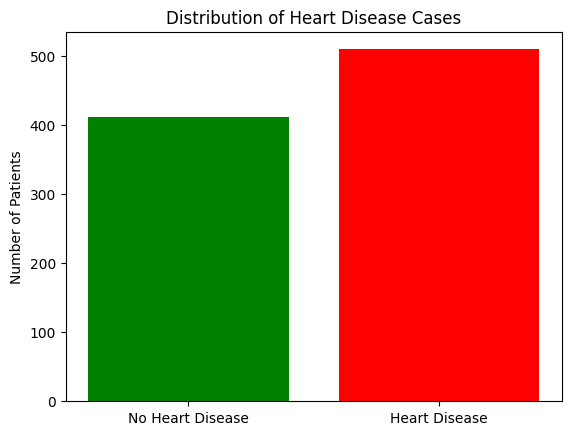

In [42]:
labels = ['No Heart Disease', 'Heart Disease']
counts = Y.value_counts().sort_index()
plt.bar(labels, counts, color=['green', 'red'])
plt.title('Distribution of Heart Disease Cases')
plt.ylabel('Number of Patients')
plt.show()

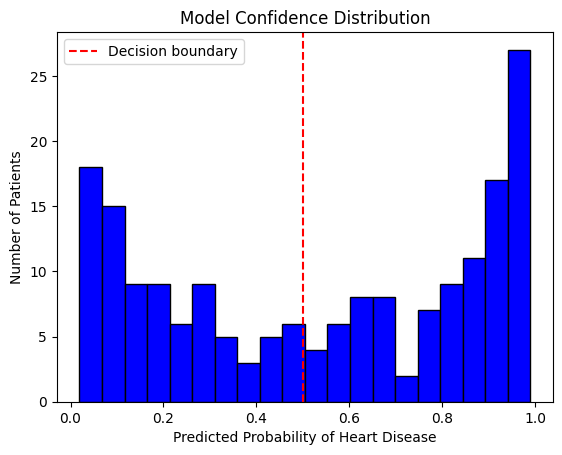

In [43]:
probabilities = model.predict_proba(x_test)[:, 1]

plt.hist(probabilities, bins=20, color='blue', edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='Decision boundary')
plt.xlabel('Predicted Probability of Heart Disease')
plt.ylabel('Number of Patients')
plt.title('Model Confidence Distribution')
plt.legend()
plt.show()

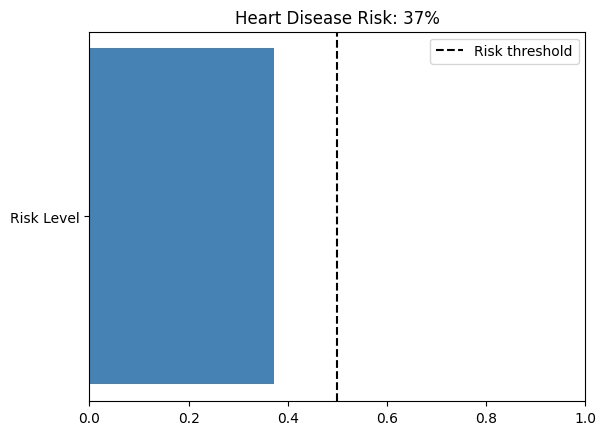

In [44]:
new_patient = pd.DataFrame([[52, 1, 4, 130, 240, 0, 0, 150, 0, 1.5, 2, 0, 3]], 
                            columns=model_data.drop(columns=['target']).columns)

probability = model.predict_proba(new_patient)[0][1]

plt.barh(['Risk Level'], [probability], color='tomato' if probability > 0.5 else 'steelblue')
plt.axvline(0.5, color='black', linestyle='--', label='Risk threshold')
plt.xlim(0, 1)
plt.title(f'Heart Disease Risk: {probability:.0%}')
plt.legend()
plt.show()

In [45]:
new_patient = pd.DataFrame([[52, 1, 4, 130, 240, 0, 0, 150, 0, 1.5, 2, 0, 3]], 
                            columns=model_data.drop(columns=['target']).columns)

prediction = model.predict(new_patient)
print("Heart Disease:", "Yes" if prediction[0] == 1 else "No")

Heart Disease: No


In [46]:
#train random forest model
#builds 200 decision trees and takes a majority vote for each prediction
#more reliable than a single model - like getting 200 doctors opinions instead of just one
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(x_train, y_train)

#generate predictions on the test set (patients model has never seen)
predictions = model.predict(x_test)
rf_predictions = rf_model.predict(x_test)

#compare accuracy of both models
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Logistic Regression Accuracy:", accuracy_score(y_test, predictions))

Random Forest Accuracy: 0.8532608695652174
Logistic Regression Accuracy: 0.8206521739130435


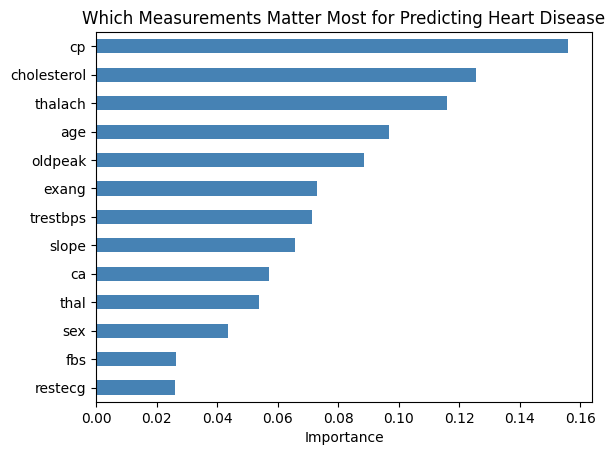

In [47]:
#feature importance - which measurements did the model rely on most?
#random forest tracks how much each feature helped across all 200 trees
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('Which Measurements Matter Most for Predicting Heart Disease')
plt.xlabel('Importance')
plt.show()
#higher score = model found this measurement more useful for predictions

In [48]:
for n in [10, 50, 100, 200, 500]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(x_train, y_train)
    preds = rf.predict(x_test)
    print(f"{n} trees: {accuracy_score(y_test, preds):.4f}")

10 trees: 0.8261
50 trees: 0.8424
100 trees: 0.8424
200 trees: 0.8533
500 trees: 0.8478


In [49]:
for seed in [1, 7, 42, 99, 123]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, Y, test_size=0.2, random_state=seed)
    rf = RandomForestClassifier(n_estimators=100, random_state=seed)
    rf.fit(X_tr, y_tr)
    preds = rf.predict(X_te)
    print(f"Seed {seed}: {accuracy_score(y_te, preds):.4f}")

Seed 1: 0.8533
Seed 7: 0.8315
Seed 42: 0.8424
Seed 99: 0.8098
Seed 123: 0.8424


In [50]:
from sklearn.model_selection import cross_val_score

#cross-validation gives a more honest accuracy than a single split
#splits data 5 different ways, tests on each, then averages the results
#this removes the luch factor of which patients end up in the test set
rf = RandomForestClassifier(n_estimators=200, random_state=42)
scores = cross_val_score(rf, X, Y, cv=5)

print("Scores per fold:", scores.round(4))
print("Average accuracy:", scores.mean().round(4))
print("Standard deviation:", scores.std().round(4))
#high standard deviation means model performance varies a lot
#this suggests we need more patient data for reliable results


Scores per fold: [0.8315 0.7174 0.8478 0.8261 0.6304]
Average accuracy: 0.7707
Standard deviation: 0.0839


In [51]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,      # number of trees
    learning_rate=0.1,     # how much each tree corrects the previous
    max_depth=4,           # how deep each tree can grow
    random_state=42,
    eval_metric='logloss'  # suppresses a warning
)

xgb_model.fit(x_train, y_train)

# Single split accuracy
xgb_predictions = xgb_model.predict(x_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print("XGBoost single split accuracy:", round(xgb_accuracy, 4))

# Cross validation for honest evaluation
xgb_cv_scores = cross_val_score(xgb_model, X, Y, cv=5)
print("XGBoost cross-validation average:", round(xgb_cv_scores.mean(), 4))
print("XGBoost cross-validation std:", round(xgb_cv_scores.std(), 4))

XGBoost single split accuracy: 0.8533
XGBoost cross-validation average: 0.725
XGBoost cross-validation std: 0.0792


In [52]:
# compare all three models
print("Model Comparison")
print("-" * 45)
print(f"Logistic Regression:  {accuracy_score(y_test, predictions):.4f} single split")
print(f"Random Forest:        {accuracy_score(y_test, rf_predictions):.4f} single split")
print(f"XGBoost:              {xgb_accuracy:.4f} single split")
print("-" * 45)
print(f"Random Forest CV:     {scores.mean():.4f} average (+/- {scores.std():.4f})")
print(f"XGBoost CV:           {xgb_cv_scores.mean():.4f} average (+/- {xgb_cv_scores.std():.4f})")

Model Comparison
---------------------------------------------
Logistic Regression:  0.8207 single split
Random Forest:        0.8533 single split
XGBoost:              0.8533 single split
---------------------------------------------
Random Forest CV:     0.7707 average (+/- 0.0839)
XGBoost CV:           0.7250 average (+/- 0.0792)


In [53]:
# Tuned XGBoost - reduce overfitting with shallower trees and slower learning
xgb_tuned = XGBClassifier(
    n_estimators=100,      # fewer trees
    learning_rate=0.05,    # slower learning
    max_depth=3,           # shallower trees reduce overfitting
    subsample=0.8,         # use 80% of data per tree
    random_state=42,
    eval_metric='logloss'
)

xgb_tuned.fit(x_train, y_train)

tuned_predictions = xgb_tuned.predict(x_test)
tuned_accuracy = accuracy_score(y_test, tuned_predictions)
print("Tuned XGBoost single split:", round(tuned_accuracy, 4))

tuned_cv_scores = cross_val_score(xgb_tuned, X, Y, cv=5)
print("Tuned XGBoost CV average:", round(tuned_cv_scores.mean(), 4))
print("Tuned XGBoost CV std:", round(tuned_cv_scores.std(), 4))

Tuned XGBoost single split: 0.8207
Tuned XGBoost CV average: 0.7913
Tuned XGBoost CV std: 0.079
